In [1]:
import os
import sys
from sys import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
from scipy.optimize import least_squares, minimize_scalar
import json
import random
from datetime import datetime, timezone
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from skyfield.api import load, EarthSatellite, Topos, wgs84
import skyfield.api as sf
from scipy.linalg import block_diag
import math
from scipy.linalg import cho_factor, cho_solve, inv
from scipy.interpolate import interp1d
from src.utils import orbcomm_utils as outils
import numbers

BDC is using numpy


In [2]:
from skyfield.api import load, wgs84
from datetime import datetime, timezone

In [3]:
satlist = [28654,25338,33591,57166,59051,44387]
coords = [79.41717895, -90.76721818, 188.095]
t_start = 1753200150
t_end = 1753286410
alt_cutoff = 10

In [4]:
tle_file = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
sats_all = sf.load.tle_file(tle_file)
sats = {sat.model.satnum: sat for sat in sats_all if sat.model.satnum in satlist}
print(len(sats))

6


In [5]:
ex = sats[59051]
observer = sf.wgs84.latlon(*coords) #for risen sats lat/lon is sufficient
ts = load.timescale()

In [6]:
t0 = ts.from_datetime(datetime.fromtimestamp(t_start, tz=timezone.utc))
t1 = ts.from_datetime(datetime.fromtimestamp(t_end, tz=timezone.utc))

In [9]:
times, events = ex.find_events(observer, t0, t1, altitude_degrees = alt_cutoff)
event_names = f'rise above {alt_cutoff}°', 'culminate', f'set below {alt_cutoff}°'

In [ ]:
print(times)
print(events)

<Time tt=[2460879.2088447413 ... 2460880.131796396] len=42>
[0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0
 1 2 0 1 2]
<Time tt=2460879.2088447413> <Time tt=2460879.216309418>


In [76]:
for ti, event in zip(times, events):
    name = event_names[event]
    print(ti.utc_strftime('%Y %b %d %H:%M:%S'), name)

2025 Jul 22 16:02:44 rise above 10°
2025 Jul 22 16:08:06 culminate
2025 Jul 22 16:13:26 set below 10°
2025 Jul 22 17:42:39 rise above 10°
2025 Jul 22 17:47:59 culminate
2025 Jul 22 17:53:18 set below 10°
2025 Jul 22 19:22:22 rise above 10°
2025 Jul 22 19:27:41 culminate
2025 Jul 22 19:32:59 set below 10°
2025 Jul 22 21:02:05 rise above 10°
2025 Jul 22 21:07:25 culminate
2025 Jul 22 21:12:46 set below 10°
2025 Jul 22 22:42:05 rise above 10°
2025 Jul 22 22:47:25 culminate
2025 Jul 22 22:52:45 set below 10°
2025 Jul 23 00:22:44 rise above 10°
2025 Jul 23 00:27:50 culminate
2025 Jul 23 00:32:56 set below 10°
2025 Jul 23 02:04:18 rise above 10°
2025 Jul 23 02:08:47 culminate
2025 Jul 23 02:13:16 set below 10°
2025 Jul 23 03:46:56 rise above 10°
2025 Jul 23 03:50:19 culminate
2025 Jul 23 03:53:43 set below 10°
2025 Jul 23 05:30:29 rise above 10°
2025 Jul 23 05:32:22 culminate
2025 Jul 23 05:34:15 set below 10°
2025 Jul 23 07:14:05 rise above 10°
2025 Jul 23 07:14:43 culminate
2025 Jul 23 07:

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from skyfield.api import load, wgs84
from datetime import datetime, timezone

def satpass_plotter(info_list, 
                    tle_path: str, 
                    global_start_time: float,
                    obscoords: tuple, 
                    step_seconds: float = 5, 
                    hard_list: list = None,
                    cmap_name: str = 'viridis'):
    """
    Plot satellite passes in a polar (alt-az) plot.

    Conventions:
      - Center = Zenith (90° altitude)
      - Outer edge = Horizon (0° altitude)
      - North = 0° azimuth, clockwise
    """
    if hard_list is None:
        hard_list = []

    obslat, obslon, obselev = obscoords
    observer = wgs84.latlon(obslat, obslon, obselev)

    # Load satellites and timescale
    sats = load.tle_file(tle_path)
    ts = load.timescale()

    pulse_data = []
    satIDs = set()

    # Collect azimuth and altitude for each pulse
    for pulse in info_list:
        (t_start, t_end), satID = pulse
        satIDs.add(satID)

        global_pulse_start = t_start + global_start_time
        dt = datetime.fromtimestamp(global_pulse_start, tz=timezone.utc)
        t0 = ts.utc(dt.year, dt.month, dt.day, dt.hour, dt.minute,
                    dt.second + dt.microsecond/1e6)

        seconds = np.arange(0, t_end - t_start, step_seconds)
        times = t0 + seconds / (24*60*60)

        sat = next((s for s in sats if s.model.satnum == satID), None)
        if sat is None:
            continue

        topocentric = (sat - observer).at(times)
        alt, az, _ = topocentric.altaz()
        az_rad = np.radians(az.degrees)
        el = alt.degrees

        pulse_data.append((satID, az_rad, el))

    # Continuous colormap for satellites
    satIDs = sorted(satIDs)
    cmap = cm.get_cmap(cmap_name, len(satIDs))
    id2colour = {sat_id: cmap(i / max(1, len(satIDs)-1)) for i, sat_id in enumerate(satIDs)}

    # Create polar plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

    for satID, az_rad, el in pulse_data:
        color = id2colour[satID]
        linewidth = 2 if satID in hard_list else 1
        # Radius = 90 - altitude: center = zenith, outer = horizon
        ax.plot(az_rad, 90 - el, color=color, linewidth=linewidth, label=f"{satID}")

    # Configure axes
    ax.set_rlim(0, 90)                       # radius from 0 (zenith) to 90 (horizon)
    ax.set_rticks([0, 15, 30, 45, 60, 75, 90])           # radial tick positions in radius units
    ax.set_yticklabels([90, 75, 60, 45, 30, 15, 0])      # show altitude labels reversed: 90° center, 0° edge
    ax.set_rlabel_position(225)              # radial labels offset
    ax.set_theta_zero_location('N')          # North at top
    ax.set_theta_direction(-1)               # clockwise
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    ax.set_xticklabels(['N', 'E', 'S', 'W'])
    #ax.set_title("Satellite Passes", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Unique legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='lower left', bbox_to_anchor=(0.9, 0))

    return fig


In [123]:
config_name = '/home/thomasb/albatros_analysis/scripts/orbcomm/config3_corr2.json'
pulsedata_name = '/scratch/thomasb/pulsedata_1753200150_len_86260_1760835173.json'
baseline_idx = 1

In [124]:
with open(config_name, "r") as f:
    config = json.load(f)
    dir_parents = []
    coords = []
    # unpack information from the json file
    # Call get_starting_index for all antennas except reference
    for i, (ant, details) in enumerate(config["antennas"].items()):
        if (i == 0) or (i ==baseline_idx):
            coords.append(details['coordinates'])
            dir_parents.append(details["path"])
    global_start_time = config["correlation"]["start_timestamp"]
    end_t = config["correlation"]["end_timestamp"]
    v_acclen = config["correlation"]["vis_acclen"]


ref_coords = coords[0]
chanlist = np.arange(1834, 1852, dtype=int)
tle_path = outils.get_tle_file(global_start_time, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

print(global_start_time)
print(tle_path)
print(coords)

1753200150
/project/rrg-sievers/mohanagr/OCOMM_TLES/2025/202507/20250722.txt
[[79.41717895, -90.76721818, 188.095], [79.41721848, -90.75872502, 183.51076468]]


In [125]:
with open(pulsedata_name, "r") as f:
    pulsedata = json.load(f)
    pl = []
    for pulse_idx, details in enumerate(pulsedata[f"{global_start_time}"]["Antenna 2"]["pulse_data"]):
        #ignore multi-sat pulses
        if len(details["sats_present"]) > 1: 
            continue
        pi = []
        start_time = details["start"] * 5
        end_time = details["end"] * 5
        pi.append([start_time, end_time])
        pi.append(int(list(details['sats_present'].keys())[0]))
        pl.append(pi)

print("pulse list", pl)
print("pulse list length", len(pl))

pulse list [[[2225, 3025], 25338], [[7850, 10450], 33591], [[17400, 20100], 59051], [[22650, 23975], 57166], [[23975, 25325], 57166], [[30325, 32550], 25338], [[32550, 33000], 25338], [[47525, 50200], 59051], [[52725, 53975], 57166], [[53975, 55425], 57166], [[60225, 62875], 25338], [[62900, 65650], 28654], [[68450, 71275], 33591], [[77875, 80325], 59051], [[82725, 84050], 57166], [[84050, 85400], 57166], [[90150, 92825], 25338], [[98675, 101475], 33591], [[108575, 110475], 59051], [[114150, 115375], 57166], [[120150, 122825], 25338], [[128850, 131675], 33591], [[139850, 140375], 59051], [[142725, 144200], 57166], [[144200, 145400], 57166], [[150350, 152850], 25338], [[159100, 161925], 33591], [[180900, 182900], 25338], [[189525, 192225], 33591], [[203275, 205575], 57166], [[211875, 212825], 25338], [[220250, 222550], 33591], [[234075, 235650], 57166], [[251375, 252850], 33591], [[262475, 263800], 59051], [[292550, 294750], 59051], [[322700, 325275], 59051], [[334450, 335500], 25338], 

/tmp/ipykernel_225985/2915356386.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(satIDs))


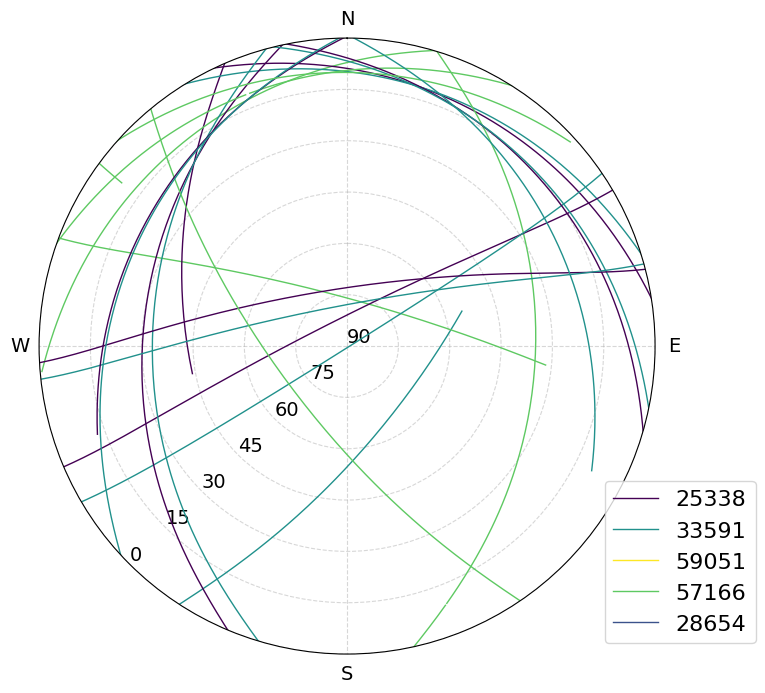

In [126]:
fig = satpass_plotter(pl, tle_path, global_start_time, coords[1])


In [ ]:
with open(pulsedata_name, "r") as f:
    pulsedata = json.load(f)
    